# Experiment 4: Telecom Customer Churn Prediction using Machine Learning


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Accuracy: 0.7778566359119943
KNN Accuracy: 0.7508871540099361
SVM Accuracy: 0.7778566359119943


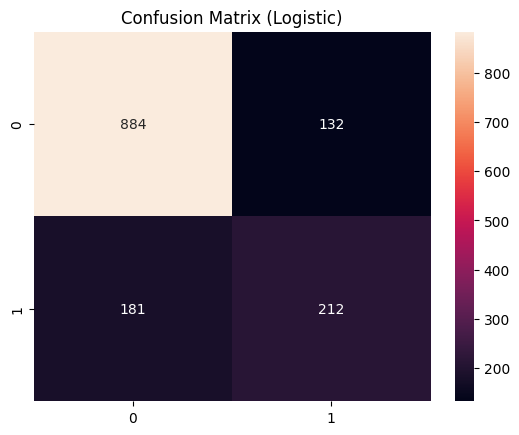

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic)")
plt.show()

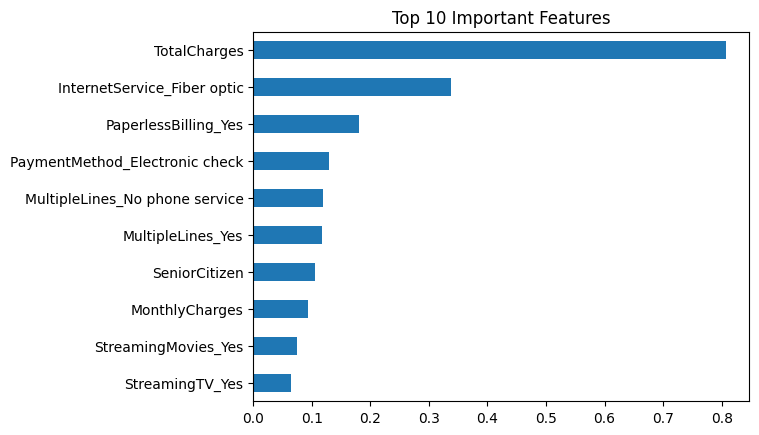

In [ ]:
feature_importance = pd.Series(lr.coef_[0], index=X.columns)

feature_importance = feature_importance.sort_values()

feature_importance.tail(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

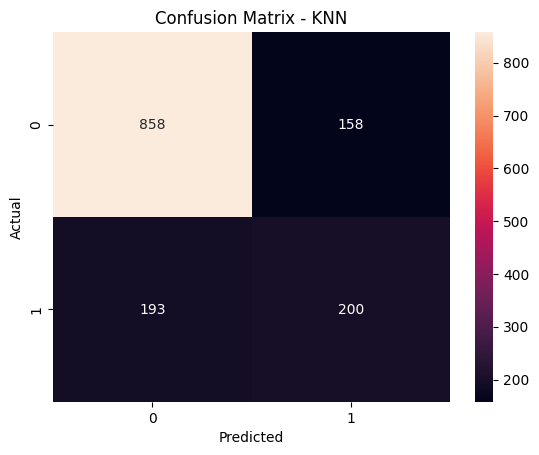

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

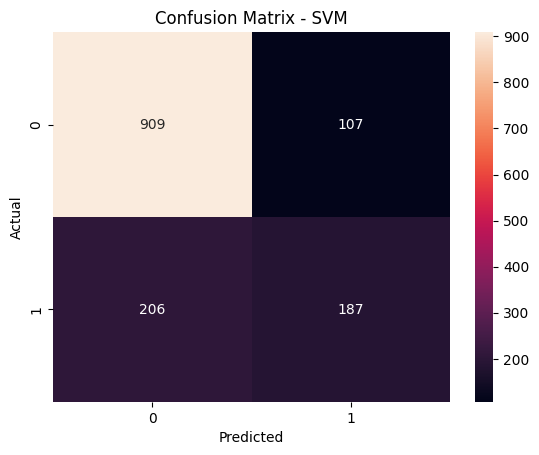

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("KNN Report:\n", classification_report(y_test, y_pred_knn))
print("SVM Report:\n", classification_report(y_test, y_pred_svm))

Logistic Regression Report:
               precision    recall  f1-score   support

       False       0.83      0.87      0.85      1016
        True       0.62      0.54      0.58       393

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409

KNN Report:
               precision    recall  f1-score   support

       False       0.82      0.84      0.83      1016
        True       0.56      0.51      0.53       393

    accuracy                           0.75      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.74      0.75      0.75      1409

SVM Report:
               precision    recall  f1-score   support

       False       0.82      0.89      0.85      1016
        True       0.64      0.48      0.54       393

    accuracy                           0.78      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       

In [ ]:
from sklearn.metrics import roc_auc_score

# LR
y_prob_lr = lr.predict_proba(X_test)[:,1]
print("LR AUC:", roc_auc_score(y_test, y_prob_lr))

# SVM (probability=True hona chahiye)
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_prob_svm = svm.predict_proba(X_test)[:,1]
print("SVM AUC:", roc_auc_score(y_test, y_prob_svm))

LR AUC: 0.8346669571837871
SVM AUC: 0.7933459057121677


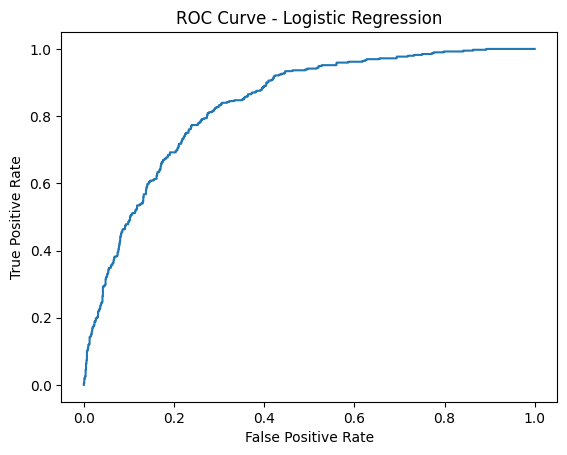

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr, tpr)
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## Conclusion
In this experiment, multiple machine learning models including Logistic Regression, KNN, and SVM were implemented to predict customer churn. The models were evaluated using accuracy. Logistic Regression provided interpretable results, while SVM showed strong classification performance.